In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset load karo
train_df = pd.read_csv('../data/raw/train.csv')
val_df = pd.read_csv('../data/raw/val.csv')
test_df = pd.read_csv('../data/raw/test.csv')

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())

Train shape: (87866, 5)
Val shape: (4887, 5)
Test shape: (4934, 5)

Columns: ['example_id', 'article', 'answer', 'question', 'options']


In [11]:
# First few rows dekho
train_df.head(3)

,example_id,article,answer,question,options
0,high19088.txt,Last week I talked with some of my students ab...,C,We can know from the passage that the author w...,['doctor' 'model' 'teacher' 'reporter']
1,high19088.txt,Last week I talked with some of my students ab...,C,Many graduates today turn to cosmetic surgery ...,['marry a better man/woman' 'become a model'\n...
2,high19088.txt,Last week I talked with some of my students ab...,D,"According to the passage, the author believes ...","['everyone should purchase perfection, whateve..."


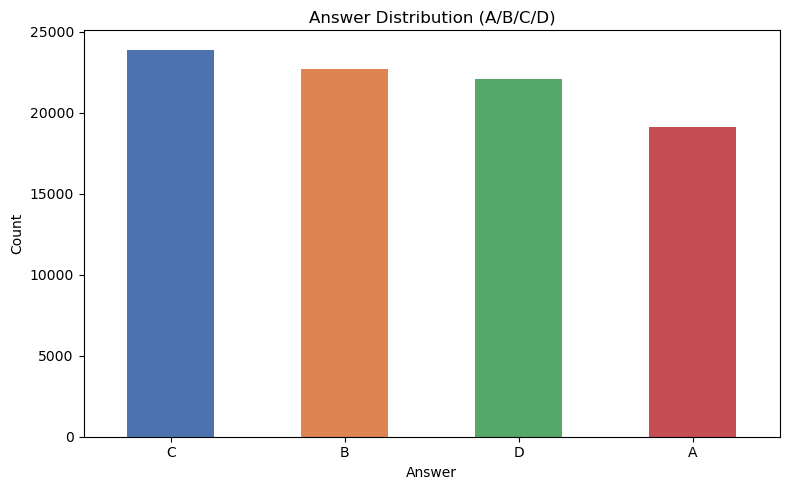

answer
C    23891
B    22726
D    22103
A    19146
Name: count, dtype: int64


In [14]:
# Answer distribution
plt.figure(figsize=(8, 5))
train_df['answer'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('Answer Distribution (A/B/C/D)')
plt.xlabel('Answer')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(train_df['answer'].value_counts())

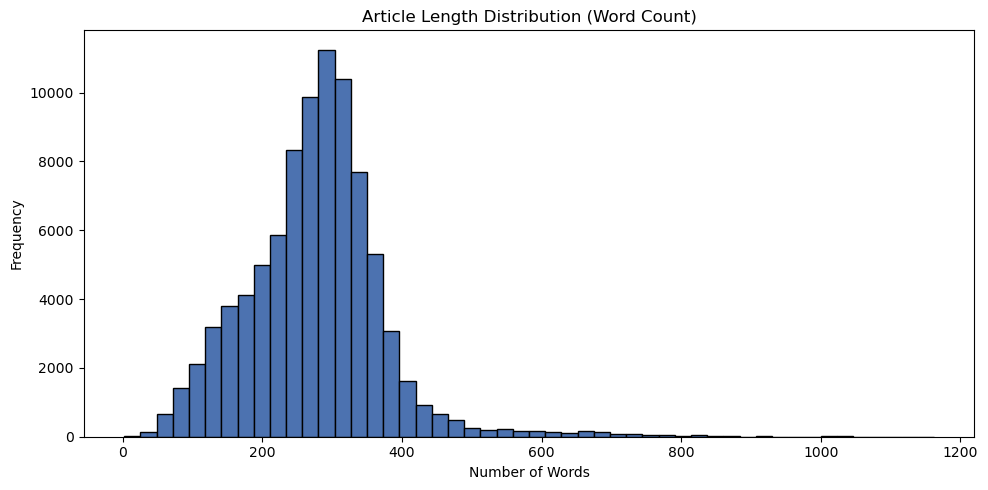

Average article length: 274.98
Max article length: 1162
Min article length: 2


In [15]:
# Article length distribution
train_df['article_length'] = train_df['article'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
plt.hist(train_df['article_length'], bins=50, color='#4C72B0', edgecolor='black')
plt.title('Article Length Distribution (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Average article length:", train_df['article_length'].mean().round(2))
print("Max article length:", train_df['article_length'].max())
print("Min article length:", train_df['article_length'].min())

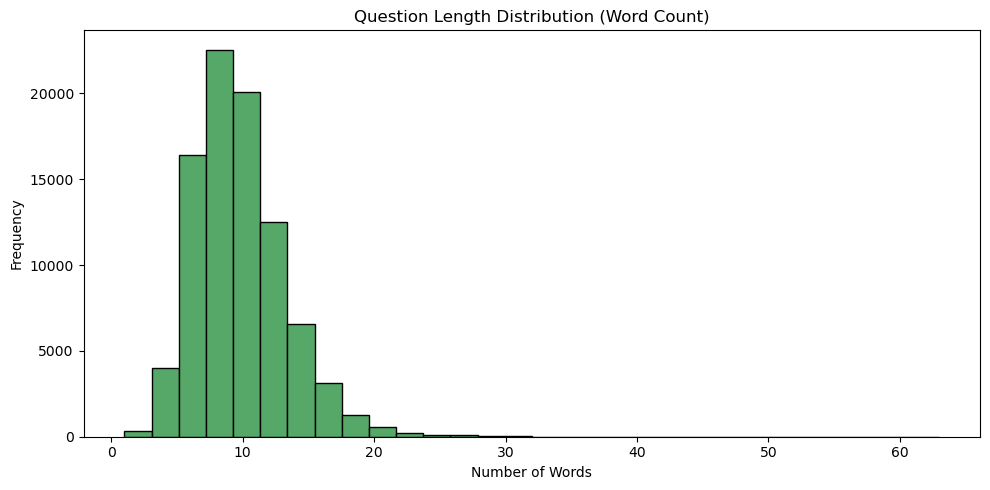

Average question length: 10.01
Max question length: 63
Min question length: 1


In [5]:
# Question length distribution
train_df['question_length'] = train_df['question'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
plt.hist(train_df['question_length'], bins=30, color='#55A868', edgecolor='black')
plt.title('Question Length Distribution (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Average question length:", train_df['question_length'].mean().round(2))
print("Max question length:", train_df['question_length'].max())
print("Min question length:", train_df['question_length'].min())

In [16]:
# Missing values check
print("=== Train Missing Values ===")
print(train_df.isnull().sum())

print("\n=== Val Missing Values ===")
print(val_df.isnull().sum())

print("\n=== Test Missing Values ===")
print(test_df.isnull().sum())


=== Train Missing Values ===
example_id           0
article              0
answer               0
question             0
options              0
options_parsed       0
avg_option_length    0
article_length       0
dtype: int64

=== Val Missing Values ===
example_id    0
article       0
answer        0
question      0
options       0
dtype: int64

=== Test Missing Values ===
example_id    0
article       0
answer        0
question      0
options       0
dtype: int64


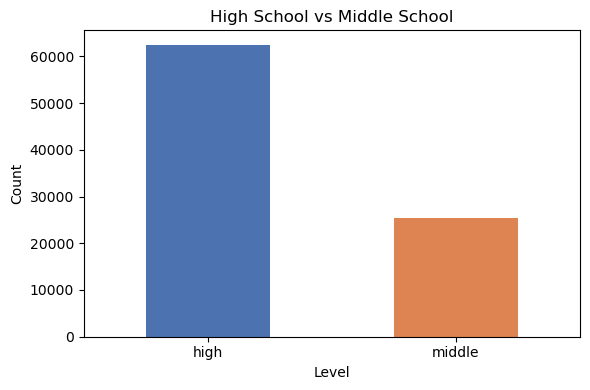

level
high      62445
middle    25421
Name: count, dtype: int64


In [19]:
# High vs Middle school
train_df['level'] = train_df['example_id'].apply(lambda x: 'high' if 'high' in x else 'middle')

plt.figure(figsize=(6, 4))
train_df['level'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('High School vs Middle School')
plt.xlabel('Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(train_df['level'].value_counts())

In [24]:
train_df['question_length'] = train_df['question'].apply(lambda x: len(x.split()))

In [25]:
# Summary statistics
print("=== Dataset Summary ===")
print(f"Total Training Samples: {len(train_df)}")
print(f"Total Validation Samples: {len(val_df)}")
print(f"Total Test Samples: {len(test_df)}")
print(f"\nAverage Article Length: {train_df['article_length'].mean().round(2)} words")
print(f"Average Question Length: {train_df['question_length'].mean().round(2)} words")
print(f"\nAnswer Balance:")
print((train_df['answer'].value_counts(normalize=True)*100).round(2))

=== Dataset Summary ===
Total Training Samples: 87866
Total Validation Samples: 4887
Total Test Samples: 4934

Average Article Length: 274.98 words
Average Question Length: 10.01 words

Answer Balance:
answer
C    27.19
B    25.86
D    25.16
A    21.79
Name: proportion, dtype: float64


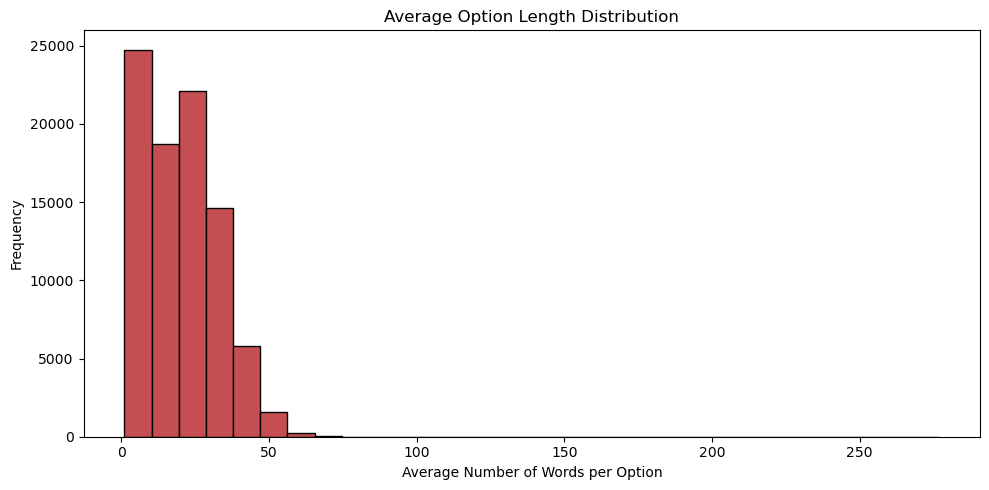

Average option length: 19.82


In [21]:
# Options length
import ast

train_df['options_parsed'] = train_df['options'].apply(ast.literal_eval)
train_df['avg_option_length'] = train_df['options_parsed'].apply(
    lambda opts: np.mean([len(o.split()) for o in opts])
)

plt.figure(figsize=(10, 5))
plt.hist(train_df['avg_option_length'], bins=30, color='#C44E52', edgecolor='black')
plt.title('Average Option Length Distribution')
plt.xlabel('Average Number of Words per Option')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Average option length:", train_df['avg_option_length'].mean().round(2))

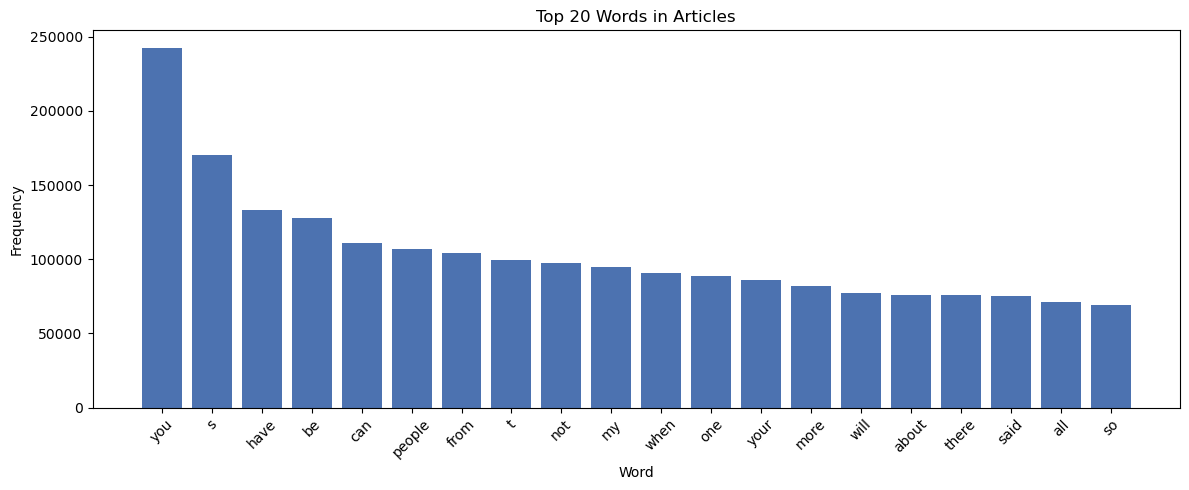

In [22]:
from collections import Counter
import re

def get_top_words(texts, n=20):
    stopwords = {'the','a','an','is','was','are','were','in','on','at','to',
                 'of','and','or','but','it','he','she','they','we','i','his',
                 'her','their','its','this','that','with','for','as','by','had'}
    all_words = []
    for text in texts:
        words = re.findall(r'\b[a-z]+\b', text.lower())
        all_words.extend([w for w in words if w not in stopwords])
    return Counter(all_words).most_common(n)

top_words = get_top_words(train_df['article'])

words, counts = zip(*top_words)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='#4C72B0')
plt.title('Top 20 Words in Articles')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import subprocess
import os

os.chdir('C:/Users/mudas/race_rc_project')

result1 = subprocess.run(['git', 'add', 'notebooks/EDA.ipynb'], capture_output=True, text=True)
result2 = subprocess.run(['git', 'commit', '-m', 'add EDA notebook'], capture_output=True, text=True)
result3 = subprocess.run(['git', 'push'], capture_output=True, text=True)

print(result2.stdout)
print(result3.stdout)
print(result3.stderr)